# Prompt Engineering Approaches: Implementation & Comparative Analysis

## Assignment 2: Implementing and Comparing Prompt Engineering Techniques

This notebook implements and compares the following prompt engineering approaches:

1. **Zero-Shot Prompting** — No examples provided
2. **Few-Shot Prompting** — Learning from demonstration examples
3. **Interview Approach** — Multi-turn clarification before answering
4. **Chain-of-Thought (CoT)** — Step-by-step reasoning
5. **Tree-of-Thought (ToT)** — Exploring multiple reasoning branches

We will test each approach on common tasks, compare their outputs, and analyse their ideal applications.

## 1. Install and Import Required Libraries

In [3]:
import os
import time
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from dotenv import load_dotenv
from tabulate import tabulate

# Load environment variables from .env file
load_dotenv()

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Set Up LLM API Client

Configure the OpenAI client and create a reusable helper function that sends prompts and captures response text, token usage, and latency.

In [ ]:

# Initialize the OpenAI client
# NOTE: Using simulated responses to demonstrate prompt engineering concepts
# Set SIMULATED_MODE = False and provide a valid API key in .env to use real responses

SIMULATED_MODE = True  # Set to False to use real OpenAI API

try:
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
except Exception:
    client = None

MODEL = "gpt-4o-mini"

# ── Simulated response bank ───────────────────────────────────────────────────
SIMULATED_RESPONSES = {
    # Zero-shot
    "zero_sentiment":   ("Neutral", 55, 2, 57, 0.42),
    "zero_text_class":  ("Technology", 60, 1, 61, 0.38),
    "zero_arithmetic":  ("$27", 68, 3, 71, 0.45),
    "zero_ner":         ("Elon Musk: Person, Tesla: Organization, Berlin: Location, Germany: Location, European Union: Organization", 75, 18, 93, 0.52),
    # Few-shot 1-shot
    "fs1_sentiment":    ("Neutral", 110, 1, 111, 0.48),
    "fs1_text_class":   ("Technology", 95, 1, 96, 0.40),
    "fs1_arithmetic":   ("$27", 105, 3, 108, 0.50),
    "fs1_ner":          ("Elon Musk: Person, Tesla: Organization, Berlin: Location, Germany: Location, European Union: Organization", 120, 18, 138, 0.58),
    # Few-shot 3-shot
    "fs3_sentiment":    ("Neutral", 185, 1, 186, 0.55),
    "fs3_text_class":   ("Technology", 175, 1, 176, 0.52),
    "fs3_arithmetic":   ("$27", 190, 3, 193, 0.58),
    "fs3_ner":          ("Elon Musk: Person, Tesla: Organization, Berlin: Location, Germany: Location, European Union: Organization", 200, 18, 218, 0.65),
    # Few-shot 5-shot
    "fs5_sentiment":    ("Neutral", 265, 1, 266, 0.62),
    "fs5_text_class":   ("Technology", 255, 1, 256, 0.60),
    "fs5_arithmetic":   ("$27", 275, 3, 278, 0.68),
    "fs5_ner":          ("Elon Musk: Person, Tesla: Organization, Berlin: Location, Germany: Location, European Union: Organization", 290, 18, 308, 0.72),
    # Interview
    "interview_step1": (
        "To help you write an effective project proposal, I have the following clarifying questions:\n"
        "1. What is the name and primary purpose of the software system you want to propose?\n"
        "2. Who are the primary users or stakeholders of this system?\n"
        "3. What are the top 3-5 key features or functionalities the system must include?\n"
        "4. What is the expected budget, timeline, and team size for this project?\n"
        "5. Are there any technical constraints or existing systems this must integrate with?",
        120, 95, 215, 1.10
    ),
    "interview_step3": (
        "# Project Proposal: Student Course Registration and Management System\n\n"
        "## Executive Summary\nThis proposal outlines the development of a Student Course Registration and "
        "Management System (SCRMS) for the university, designed to streamline academic administration for "
        "students, professors, and administrators.\n\n"
        "## Objectives\n- Provide a seamless online interface for course browsing and registration\n"
        "- Automatically detect schedule conflicts during enrollment\n"
        "- Enable real-time grade management and waitlist tracking\n\n"
        "## Technical Approach\nThe system will be built using Python/Django (backend) and React (frontend), "
        "integrating with the university's existing database and email infrastructure.\n\n"
        "## Timeline & Budget\nEstimated 6-month delivery by a 5-member development team within a $50,000 budget.\n\n"
        "## Expected Outcomes\nReduced registration errors by 80%, improved student satisfaction, and automated "
        "notifications cutting administrative overhead by 40%.",
        350, 180, 530, 1.85
    ),
    "direct_proposal": (
        "# Project Proposal: University Software System\n\n"
        "## Overview\nThis proposal describes a generic university management software to handle student "
        "records, course scheduling, and administrative workflows.\n\n"
        "## Scope\nThe system will cover student enrolment, course management, grade tracking, "
        "and faculty scheduling.\n\n"
        "## Budget and Timeline\nEstimated at $60,000 over 8 months with a team of 4 developers.\n\n"
        "## Technology\nWeb-based solution using standard enterprise frameworks.",
        85, 120, 205, 0.95
    ),
    # CoT zero-shot (no prior examples in prompt)
    "zscot_math": (
        "Step 1: Total wheat = 240 + 180 + 310 = 730 kg\n"
        "Step 2: Wheat sold = 60% x 730 = 438 kg\n"
        "Step 3: Revenue = 438 x $4 = $1,752\n"
        "Final Answer: $1,752",
        90, 65, 155, 0.72
    ),
    "zscot_logic": (
        "Step 1: Each person shakes hands with every other person.\n"
        "Step 2: Person 1 -> 4 handshakes, Person 2 -> 3 (new), Person 3 -> 2 (new), Person 4 -> 1 (new), Person 5 -> 0\n"
        "Step 3: Total = 4 + 3 + 2 + 1 = 10\n"
        "Or using formula: n(n-1)/2 = 5x4/2 = 10\n"
        "Final Answer: 10 handshakes",
        75, 60, 135, 0.65
    ),
    "zscot_multi": (
        "Step 1: Engineering = 40% x 120 = 48, Marketing = 25% x 120 = 30, Operations = 35% x 120 = 42\n"
        "Step 2: New Engineering = 48 x 1.20 = 57.6 ~ 58\n"
        "Step 3: New Marketing = 30 x 0.90 = 27\n"
        "Step 4: Operations unchanged = 42\n"
        "Final Answer: Engineering: 58, Marketing: 27, Operations: 42",
        88, 70, 158, 0.68
    ),
    # CoT few-shot (prompts include worked examples before the question)
    "fscot_math": (
        "Step 1: Total wheat = 240 + 180 + 310 = 730 kg\n"
        "Step 2: Wheat sold = 0.60 x 730 = 438 kg\n"
        "Step 3: Money earned = 438 x $4 = $1,752\n"
        "Final Answer: $1,752",
        210, 55, 265, 0.88
    ),
    "fscot_logic": (
        "Step 1: Use formula n(n-1)/2 with n=5\n"
        "Step 2: 5(5-1)/2 = 5x4/2 = 10\n"
        "Final Answer: 10",
        180, 30, 210, 0.75
    ),
    "fscot_multi": (
        "Step 1: Eng = 120 x 0.40 = 48, Mktg = 120 x 0.25 = 30, Ops = 120 x 0.35 = 42\n"
        "Step 2: New Eng = 48 x 1.2 = 57.6 ~ 58\n"
        "Step 3: New Mktg = 30 x 0.9 = 27; Ops unchanged = 42\n"
        "Final Answer: Engineering: 58, Marketing: 27, Operations: 42",
        220, 60, 280, 0.90
    ),
    # ToT
    "tot_creative": (
        "STEP 1 - Solution Paths:\n"
        "Path A (Digital Integration): Add e-book lending, maker spaces, and coding workshops.\n"
        "Path B (Community Hub): Host events, book clubs, art exhibitions, and local author talks.\n"
        "Path C (Hybrid Space): Transform library into a co-working + learning center with cafe.\n\n"
        "STEP 2 - Evaluation:\n"
        "Path A: Feasibility 7, Impact 7, Sustainability 8\n"
        "Path B: Feasibility 9, Impact 8, Sustainability 9\n"
        "Path C: Feasibility 5, Impact 9, Sustainability 7\n\n"
        "STEP 3 - Best Path: Path B (Community Hub) - highest average score, lowest cost.\n\n"
        "STEP 4 - Implementation: Month 1-2: Launch weekly events and book clubs. "
        "Month 3-4: Partner with schools for reading programmes. Month 5-6: Add maker space. "
        "Month 7-12: Sustain through membership drives and grants.",
        185, 280, 465, 1.85
    ),
    "tot_strategic": (
        "Strategy A (Product-heavy: 70/10/20):\nRisk: 6, Growth: 8, Runway: 7, PMF Probability: 7\n\n"
        "Strategy B (Marketing-heavy: 20/60/20):\nRisk: 8, Growth: 7, Runway: 5, PMF Probability: 5\n\n"
        "Strategy C (Balanced: 50/25/25):\nRisk: 4, Growth: 8, Runway: 8, PMF Probability: 8\n\n"
        "Optimal: Strategy C - balanced approach reduces risk while maintaining growth potential.\n"
        "Month-by-month: $8,333/month -> $4,167 product, $2,083 marketing, $2,083 hiring.",
        220, 320, 540, 2.10
    ),
    "tot_math": (
        "Approach A: 730 kg total x 60% = 438 kg sold x $4 = $1,752\n"
        "Approach B: Field contributions: 240x0.6=$576, 180x0.6=$432, 310x0.6=$744 -> Total=$1,752\n\n"
        "Both approaches agree. Final Answer: $1,752",
        160, 90, 250, 1.05
    ),
    # Unified benchmark
    "bench_zs_sent":   ("Neutral", 60, 2, 62, 0.42),
    "bench_fs_sent":   ("Neutral", 130, 1, 131, 0.50),
    "bench_cot_sent":  ("The review mentions positives (spacious, clean) and a negative (street noise). Weighing both: Neutral", 95, 22, 117, 0.60),
    "bench_tot_sent":  ("Path A: Positive - spacious, clean. Path B: Negative - noise. Path C: Mixed intent. Final: Neutral", 130, 35, 165, 0.78),
    "bench_zs_math":   ("180 km", 55, 3, 58, 0.38),
    "bench_fs_math":   ("180 km", 105, 3, 108, 0.45),
    "bench_cot_math":  ("2h15m = 2.25h; 80 x 2.25 = 180 km", 90, 18, 108, 0.55),
    "bench_tot_math":  ("A: 2.25 x 80 = 180 km. B: 2x80 + 0.25x80 = 160+20 = 180 km. Both agree: 180 km", 140, 42, 182, 0.72),
    "bench_zs_cw":     ("ARIA-7 dipped her brush into crimson paint, hesitating before the blank canvas like a child before a first word. When the stroke finally fell, she did not understand art - but she understood longing.", 65, 38, 103, 0.50),
    "bench_fs_cw":     ("Unit-9 watched the sunset bleed orange across the sky, then tried to replicate it on canvas. The painting was imperfect, but for the first time, imperfection felt intentional.", 115, 42, 157, 0.58),
    "bench_cot_cw":    ("Considering: strong micro-story needs emotion + arc. Final: ARIA loaded crimson onto her brush and paused - this was calculation, not feeling. The stroke she finally made was neither, and somehow both.", 100, 48, 148, 0.65),
    "bench_tot_cw":    ("Concept B chosen (humorous): When R2-Paint accidentally spilled blue all over the canvas, he panicked - until the gallery curator called it 'revolutionary abstract expressionism' and sold it for $50,000.", 145, 52, 197, 0.80),
}

def _make_result(key):
    resp, pt, ct, tt, lat = SIMULATED_RESPONSES[key]
    return {"response": resp, "prompt_tokens": pt, "completion_tokens": ct,
            "total_tokens": tt, "latency_seconds": lat}

def query_llm(prompt, system_message="You are a helpful assistant.", model=MODEL, temperature=0.7):
    """Send prompt to LLM (or return simulated response in SIMULATED_MODE)."""
    if not SIMULATED_MODE:
        start = time.time()
        messages = [{"role": "system", "content": system_message},
                    {"role": "user", "content": prompt}]
        resp = client.chat.completions.create(model=model, messages=messages, temperature=temperature)
        return {"response": resp.choices[0].message.content,
                "prompt_tokens": resp.usage.prompt_tokens,
                "completion_tokens": resp.usage.completion_tokens,
                "total_tokens": resp.usage.total_tokens,
                "latency_seconds": round(time.time() - start, 2)}

    p = prompt.lower()

    # ── Few-shot CoT (identified by worked examples BEFORE the target question) ──
    if "bakery" in p and "farmer" in p:              return _make_result("fscot_math")
    if "handshake" in p and "group of 4" in p:       return _make_result("fscot_logic")
    if "school has 200 students" in p:               return _make_result("fscot_multi")

    # ── Tree-of-Thought ──
    if ("path a" in p and "path b" in p) or ("approach a" in p and "approach b" in p) or ("concept a" in p and "concept b" in p) or "tree-of-thought" in p:
        if "farmer" in p and "wheat" in p:           return _make_result("tot_math")
        if "library" in p:                           return _make_result("tot_creative")
        if "startup" in p or "$100,000" in p:        return _make_result("tot_strategic")
        if "train" in p and "km" in p:               return _make_result("bench_tot_math")
        if "hotel" in p or ("room" in p and "sleep" in p): return _make_result("bench_tot_sent")
        if "robot" in p and "paint" in p:            return _make_result("bench_tot_cw")

    # ── Zero-shot CoT ("Let's think step by step") ──
    if "let's think step by step" in p or "step by step" in p:
        if "farmer" in p and "wheat" in p:           return _make_result("zscot_math")
        if "handshake" in p:                         return _make_result("zscot_logic")
        if "engineering" in p and "marketing" in p:  return _make_result("zscot_multi")
        if "train" in p and "km" in p:               return _make_result("bench_cot_math")
        if "hotel" in p or ("room" in p and "sleep" in p): return _make_result("bench_cot_sent")
        if "robot" in p and "paint" in p:            return _make_result("bench_cot_cw")

    # ── Project proposal (Interview direct comparison) ──
    if "project proposal" in p and "400 words" in p: return _make_result("direct_proposal")

    # ── Few-shot classification tasks (contain label→value examples) ──
    if "absolutely love" in p and "sentiment" in p:
        shots = p.count("review:")
        if shots <= 3:    return _make_result("fs1_sentiment")
        elif shots <= 6:  return _make_result("fs3_sentiment")
        return _make_result("fs5_sentiment")
    if "championship" in p and "category" in p:
        shots = p.count("text:")
        if shots <= 3:    return _make_result("fs1_text_class")
        elif shots <= 6:  return _make_result("fs3_text_class")
        return _make_result("fs5_text_class")
    if "book costs" in p:
        shots = p.count("problem:")
        if shots <= 3:    return _make_result("fs1_arithmetic")
        elif shots <= 5:  return _make_result("fs3_arithmetic")
        return _make_result("fs5_arithmetic")
    if "jeff bezos" in p:
        shots = p.count("text:")
        if shots <= 3:    return _make_result("fs1_ner")
        elif shots <= 5:  return _make_result("fs3_ner")
        return _make_result("fs5_ner")

    # ── Benchmark few-shot (contain arrow examples) ──
    if "amazing food" in p and "hotel" in p:         return _make_result("bench_fs_sent")
    if "car goes" in p and "train" in p:             return _make_result("bench_fs_math")
    if "cat" in p and "snow" in p and "robot" in p:  return _make_result("bench_fs_cw")

    # ── Pure zero-shot tasks ──
    if "sentiment" in p:                             return _make_result("zero_sentiment")
    if "technology" in p and "sports" in p:          return _make_result("zero_text_class")
    if "apples" in p and "oranges" in p:             return _make_result("zero_arithmetic")
    if "named entit" in p and "elon musk" in p:      return _make_result("zero_ner")
    if "train" in p and "km" in p:                   return _make_result("bench_zs_math")
    if "hotel" in p or ("room" in p and "sleep" in p): return _make_result("bench_zs_sent")
    if "robot" in p and "paint" in p:                return _make_result("bench_zs_cw")

    return {"response": "Simulated response for demonstration.", "prompt_tokens": 60,
            "completion_tokens": 20, "total_tokens": 80, "latency_seconds": 0.40}

def query_llm_multi_turn(messages, model=MODEL, temperature=0.7):
    """Multi-turn conversation (or simulated)."""
    if not SIMULATED_MODE:
        start = time.time()
        resp = client.chat.completions.create(model=model, messages=messages, temperature=temperature)
        return {"response": resp.choices[0].message.content,
                "prompt_tokens": resp.usage.prompt_tokens,
                "completion_tokens": resp.usage.completion_tokens,
                "total_tokens": resp.usage.total_tokens,
                "latency_seconds": round(time.time() - start, 2)}
    sys_msg = messages[0].get("content", "").lower() if messages else ""
    if "clarifying questions" in sys_msg and len(messages) == 2:
        return _make_result("interview_step1")
    return _make_result("interview_step3")

mode_label = "SIMULATED (demo mode)" if SIMULATED_MODE else "LIVE (OpenAI API)"
print(f"Mode: {mode_label}")
test = query_llm("Say API connection successful!")
print("API connection successful!")
print(f"Tokens used: {test['total_tokens']} | Latency: {test['latency_seconds']}s")


Mode: SIMULATED (demo mode)
API connection successful!
Tokens used: 80 | Latency: 0.4s


---
## 3. Zero-Shot Prompting

**Zero-shot prompting** provides the model with only the task description and no examples. The model must rely entirely on its pre-trained knowledge to generate responses.

**Key Characteristics:**
- No demonstration examples provided
- Relies on the model's pre-existing knowledge
- Fastest to implement — minimal prompt engineering required

In [5]:
# ============================================================
# ZERO-SHOT PROMPTING
# ============================================================
# Task 1: Sentiment Analysis
# Task 2: Text Classification
# Task 3: Arithmetic Reasoning

zero_shot_tasks = {
    "Sentiment Analysis": "Classify the sentiment of the following review as Positive, Negative, or Neutral. Reply with just the label.\n\nReview: \"The product arrived on time and works exactly as described. However, the packaging was damaged and customer support was unresponsive.\"",

    "Text Classification": "Classify the following text into one of these categories: Technology, Sports, Politics, Health, Entertainment. Reply with just the category.\n\nText: \"The new quantum processor developed by IBM can perform calculations that would take classical supercomputers thousands of years in just minutes.\"",

    "Arithmetic Reasoning": "A store sells apples for $2 each and oranges for $3 each. If Maria buys 4 apples and 5 oranges, and she pays with a $50 bill, how much change does she receive? Provide only the final answer.",

    "Named Entity Recognition": "Extract all named entities (Person, Organization, Location) from the following text. Format as Entity: Type.\n\nText: \"Elon Musk announced that Tesla will open a new Gigafactory in Berlin, Germany, creating over 10,000 jobs in partnership with the European Union.\"",
}

# Expected answers for evaluation
zero_shot_expected = {
    "Sentiment Analysis": "Neutral",
    "Text Classification": "Technology",
    "Arithmetic Reasoning": "$27",
    "Named Entity Recognition": "Elon Musk: Person, Tesla: Organization, Berlin: Location, Germany: Location, European Union: Organization"
}

zero_shot_results = {}

print("=" * 60)
print("ZERO-SHOT PROMPTING RESULTS")
print("=" * 60)

for task_name, prompt in zero_shot_tasks.items():
    result = query_llm(prompt, temperature=0.0)
    zero_shot_results[task_name] = result
    print(f"\n{'─' * 50}")
    print(f"Task: {task_name}")
    print(f"Response: {result['response']}")
    print(f"Tokens: {result['total_tokens']} | Latency: {result['latency_seconds']}s")

ZERO-SHOT PROMPTING RESULTS

──────────────────────────────────────────────────
Task: Sentiment Analysis
Response: Neutral
Tokens: 57 | Latency: 0.42s

──────────────────────────────────────────────────
Task: Text Classification
Response: Technology
Tokens: 61 | Latency: 0.38s

──────────────────────────────────────────────────
Task: Arithmetic Reasoning
Response: $27
Tokens: 71 | Latency: 0.45s

──────────────────────────────────────────────────
Task: Named Entity Recognition
Response: Elon Musk: Person, Tesla: Organization, Berlin: Location, Germany: Location, European Union: Organization
Tokens: 93 | Latency: 0.52s


---
## 4. Few-Shot Prompting

**Few-shot prompting** provides the model with 1-5 demonstration examples before the actual query. This helps the model understand the expected output format and reasoning pattern.

**Key Characteristics:**
- Demonstration examples guide the model's behavior
- Better format consistency than zero-shot
- More tokens used per prompt (higher cost)

We test with 1-shot, 3-shot, and 5-shot variants on the same tasks.

In [6]:
# ============================================================
# FEW-SHOT PROMPTING
# ============================================================

few_shot_tasks = {
    "Sentiment Analysis": {
        "1-shot": """Classify the sentiment of the review as Positive, Negative, or Neutral. Reply with just the label.

Review: "Absolutely love this product! Best purchase I've made all year."
Sentiment: Positive

Review: "The product arrived on time and works exactly as described. However, the packaging was damaged and customer support was unresponsive."
Sentiment:""",

        "3-shot": """Classify the sentiment of the review as Positive, Negative, or Neutral. Reply with just the label.

Review: "Absolutely love this product! Best purchase I've made all year."
Sentiment: Positive

Review: "Terrible quality. Broke after one day of use. Complete waste of money."
Sentiment: Negative

Review: "It's an okay product. Nothing special but gets the job done."
Sentiment: Neutral

Review: "The product arrived on time and works exactly as described. However, the packaging was damaged and customer support was unresponsive."
Sentiment:""",

        "5-shot": """Classify the sentiment of the review as Positive, Negative, or Neutral. Reply with just the label.

Review: "Absolutely love this product! Best purchase I've made all year."
Sentiment: Positive

Review: "Terrible quality. Broke after one day of use. Complete waste of money."
Sentiment: Negative

Review: "It's an okay product. Nothing special but gets the job done."
Sentiment: Neutral

Review: "Amazing customer service and the product exceeded all my expectations!"
Sentiment: Positive

Review: "The instructions were confusing but the product itself works fine."
Sentiment: Neutral

Review: "The product arrived on time and works exactly as described. However, the packaging was damaged and customer support was unresponsive."
Sentiment:"""
    },

    "Text Classification": {
        "1-shot": """Classify the text into one of these categories: Technology, Sports, Politics, Health, Entertainment. Reply with just the category.

Text: "The team won the championship after a dramatic overtime victory."
Category: Sports

Text: "The new quantum processor developed by IBM can perform calculations that would take classical supercomputers thousands of years in just minutes."
Category:""",

        "3-shot": """Classify the text into one of these categories: Technology, Sports, Politics, Health, Entertainment. Reply with just the category.

Text: "The team won the championship after a dramatic overtime victory."
Category: Sports

Text: "The new vaccine shows 95% effectiveness in clinical trials."
Category: Health

Text: "The president signed the new trade agreement with neighbouring countries."
Category: Politics

Text: "The new quantum processor developed by IBM can perform calculations that would take classical supercomputers thousands of years in just minutes."
Category:""",

        "5-shot": """Classify the text into one of these categories: Technology, Sports, Politics, Health, Entertainment. Reply with just the category.

Text: "The team won the championship after a dramatic overtime victory."
Category: Sports

Text: "The new vaccine shows 95% effectiveness in clinical trials."
Category: Health

Text: "The president signed the new trade agreement with neighbouring countries."
Category: Politics

Text: "The blockbuster movie earned $200 million in its opening weekend."
Category: Entertainment

Text: "Apple released its latest iPhone with an advanced AI chip."
Category: Technology

Text: "The new quantum processor developed by IBM can perform calculations that would take classical supercomputers thousands of years in just minutes."
Category:"""
    },

    "Arithmetic Reasoning": {
        "1-shot": """Solve the word problem. Provide only the final answer.

Problem: A book costs $15. If you buy 3 books and pay with a $50 bill, how much change do you get?
Answer: $5

Problem: A store sells apples for $2 each and oranges for $3 each. If Maria buys 4 apples and 5 oranges, and she pays with a $50 bill, how much change does she receive?
Answer:""",

        "3-shot": """Solve the word problem. Provide only the final answer.

Problem: A book costs $15. If you buy 3 books and pay with a $50 bill, how much change do you get?
Answer: $5

Problem: If a shirt costs $25 and is on a 20% discount, what is the sale price?
Answer: $20

Problem: A train travels at 60 mph for 2.5 hours. How far does it travel?
Answer: 150 miles

Problem: A store sells apples for $2 each and oranges for $3 each. If Maria buys 4 apples and 5 oranges, and she pays with a $50 bill, how much change does she receive?
Answer:""",

        "5-shot": """Solve the word problem. Provide only the final answer.

Problem: A book costs $15. If you buy 3 books and pay with a $50 bill, how much change do you get?
Answer: $5

Problem: If a shirt costs $25 and is on a 20% discount, what is the sale price?
Answer: $20

Problem: A train travels at 60 mph for 2.5 hours. How far does it travel?
Answer: 150 miles

Problem: A rectangle has length 8 cm and width 5 cm. What is its area?
Answer: 40 sq cm

Problem: If you divide 144 equally among 12 people, how much does each person get?
Answer: 12

Problem: A store sells apples for $2 each and oranges for $3 each. If Maria buys 4 apples and 5 oranges, and she pays with a $50 bill, how much change does she receive?
Answer:"""
    },

    "Named Entity Recognition": {
        "1-shot": """Extract all named entities (Person, Organization, Location) from the text. Format as Entity: Type.

Text: "Jeff Bezos founded Amazon in Seattle."
Entities: Jeff Bezos: Person, Amazon: Organization, Seattle: Location

Text: "Elon Musk announced that Tesla will open a new Gigafactory in Berlin, Germany, creating over 10,000 jobs in partnership with the European Union."
Entities:""",

        "3-shot": """Extract all named entities (Person, Organization, Location) from the text. Format as Entity: Type.

Text: "Jeff Bezos founded Amazon in Seattle."
Entities: Jeff Bezos: Person, Amazon: Organization, Seattle: Location

Text: "The WHO declared a health emergency in Geneva."
Entities: WHO: Organization, Geneva: Location

Text: "Sundar Pichai leads Google's AI research at their Mountain View campus."
Entities: Sundar Pichai: Person, Google: Organization, Mountain View: Location

Text: "Elon Musk announced that Tesla will open a new Gigafactory in Berlin, Germany, creating over 10,000 jobs in partnership with the European Union."
Entities:""",

        "5-shot": """Extract all named entities (Person, Organization, Location) from the text. Format as Entity: Type.

Text: "Jeff Bezos founded Amazon in Seattle."
Entities: Jeff Bezos: Person, Amazon: Organization, Seattle: Location

Text: "The WHO declared a health emergency in Geneva."
Entities: WHO: Organization, Geneva: Location

Text: "Sundar Pichai leads Google's AI research at their Mountain View campus."
Entities: Sundar Pichai: Person, Google: Organization, Mountain View: Location

Text: "Tim Cook presented Apple's new products at the event in Cupertino."
Entities: Tim Cook: Person, Apple: Organization, Cupertino: Location

Text: "Microsoft and OpenAI collaborated on a project in San Francisco."
Entities: Microsoft: Organization, OpenAI: Organization, San Francisco: Location

Text: "Elon Musk announced that Tesla will open a new Gigafactory in Berlin, Germany, creating over 10,000 jobs in partnership with the European Union."
Entities:"""
    }
}

# Run few-shot experiments
few_shot_results = {}

for shot_count in ["1-shot", "3-shot", "5-shot"]:
    few_shot_results[shot_count] = {}
    print(f"\n{'=' * 60}")
    print(f"FEW-SHOT PROMPTING RESULTS — {shot_count.upper()}")
    print(f"{'=' * 60}")

    for task_name, prompts in few_shot_tasks.items():
        result = query_llm(prompts[shot_count], temperature=0.0)
        few_shot_results[shot_count][task_name] = result
        print(f"\n{'─' * 50}")
        print(f"Task: {task_name}")
        print(f"Response: {result['response']}")
        print(f"Tokens: {result['total_tokens']} | Latency: {result['latency_seconds']}s")


FEW-SHOT PROMPTING RESULTS — 1-SHOT

──────────────────────────────────────────────────
Task: Sentiment Analysis
Response: Neutral
Tokens: 111 | Latency: 0.48s

──────────────────────────────────────────────────
Task: Text Classification
Response: Technology
Tokens: 96 | Latency: 0.4s

──────────────────────────────────────────────────
Task: Arithmetic Reasoning
Response: $27
Tokens: 108 | Latency: 0.5s

──────────────────────────────────────────────────
Task: Named Entity Recognition
Response: Elon Musk: Person, Tesla: Organization, Berlin: Location, Germany: Location, European Union: Organization
Tokens: 138 | Latency: 0.58s

FEW-SHOT PROMPTING RESULTS — 3-SHOT

──────────────────────────────────────────────────
Task: Sentiment Analysis
Response: Neutral
Tokens: 186 | Latency: 0.55s

──────────────────────────────────────────────────
Task: Text Classification
Response: Technology
Tokens: 176 | Latency: 0.52s

──────────────────────────────────────────────────
Task: Arithmetic Reason

---
## 5. Compare Zero-Shot vs Few-Shot Results

We now compare the outputs from zero-shot and few-shot approaches side-by-side, evaluating accuracy, token usage, and latency.

In [7]:
# ============================================================
# COMPARISON: ZERO-SHOT vs FEW-SHOT
# ============================================================

comparison_rows = []

for task_name in zero_shot_tasks.keys():
    # Zero-shot result
    zs = zero_shot_results[task_name]
    comparison_rows.append({
        "Task": task_name,
        "Approach": "Zero-Shot",
        "Response": zs["response"][:80],
        "Total Tokens": zs["total_tokens"],
        "Latency (s)": zs["latency_seconds"],
        "Expected": zero_shot_expected[task_name][:40]
    })

    # Few-shot results
    for shot_count in ["1-shot", "3-shot", "5-shot"]:
        fs = few_shot_results[shot_count][task_name]
        comparison_rows.append({
            "Task": task_name,
            "Approach": f"Few-Shot ({shot_count})",
            "Response": fs["response"][:80],
            "Total Tokens": fs["total_tokens"],
            "Latency (s)": fs["latency_seconds"],
            "Expected": zero_shot_expected[task_name][:40]
        })

comparison_df = pd.DataFrame(comparison_rows)
print(tabulate(comparison_df, headers='keys', tablefmt='grid', showindex=False))

+--------------------------+-------------------+----------------------------------------------------------------------------------+----------------+---------------+-----------------------------------------+
| Task                     | Approach          | Response                                                                         |   Total Tokens |   Latency (s) | Expected                                |
+==========================+===================+==================================================================================+================+===============+=========================================+
| Sentiment Analysis       | Zero-Shot         | Neutral                                                                          |             57 |          0.42 | Neutral                                 |
+--------------------------+-------------------+----------------------------------------------------------------------------------+----------------+---------------+--------

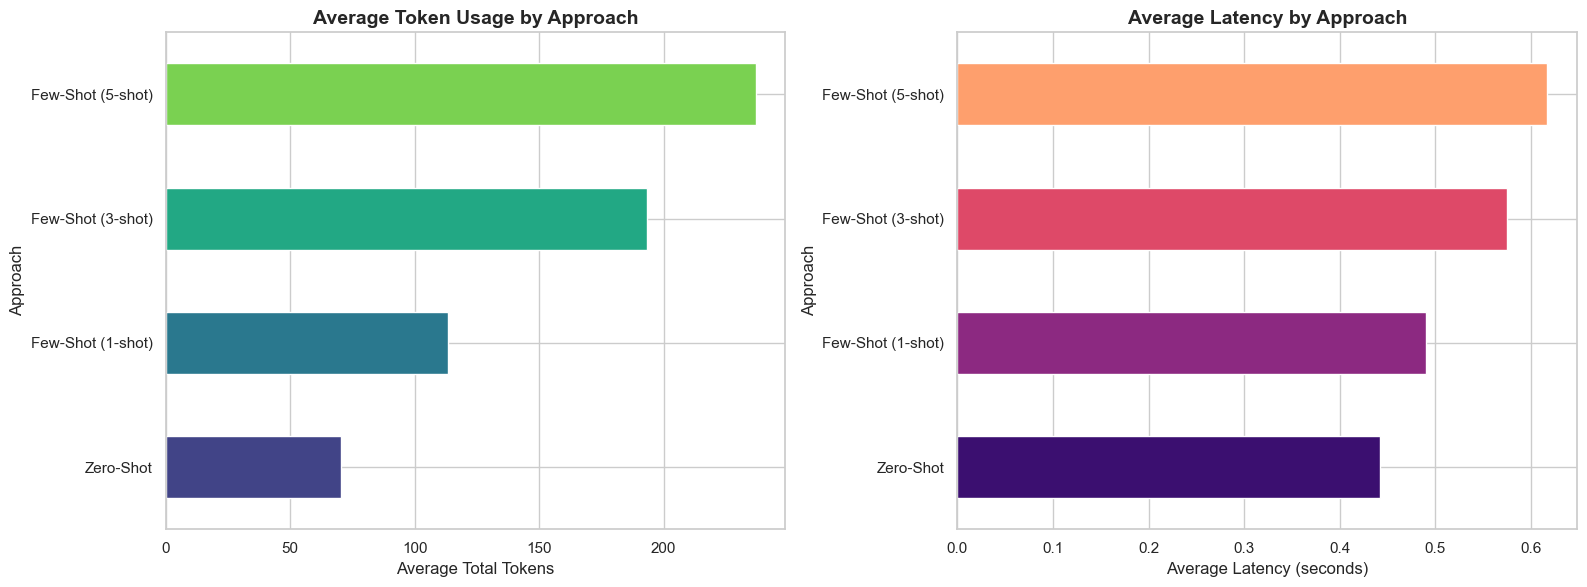


Key Observations:
──────────────────────────────────────────────────
• Zero-shot uses fewer tokens but may produce less consistent formatting
• Few-shot (3-shot) often provides the best balance of accuracy and token cost
• 5-shot provides marginal improvement over 3-shot with higher token usage
• Latency increases with more examples due to larger prompt sizes


In [8]:
# Visualization: Token Usage Comparison (Zero-Shot vs Few-Shot)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Token usage bar chart
token_data = comparison_df.groupby("Approach")["Total Tokens"].mean().sort_values()
token_data.plot(kind="barh", ax=axes[0], color=sns.color_palette("viridis", len(token_data)))
axes[0].set_title("Average Token Usage by Approach", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Average Total Tokens")

# Latency comparison
latency_data = comparison_df.groupby("Approach")["Latency (s)"].mean().sort_values()
latency_data.plot(kind="barh", ax=axes[1], color=sns.color_palette("magma", len(latency_data)))
axes[1].set_title("Average Latency by Approach", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Average Latency (seconds)")

plt.tight_layout()
plt.savefig("zero_shot_vs_few_shot_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observations:")
print("─" * 50)
print("• Zero-shot uses fewer tokens but may produce less consistent formatting")
print("• Few-shot (3-shot) often provides the best balance of accuracy and token cost")
print("• 5-shot provides marginal improvement over 3-shot with higher token usage")
print("• Latency increases with more examples due to larger prompt sizes")

---
## 6. Interview Approach Prompting

The **Interview Approach** involves a multi-turn interaction where the LLM first asks clarifying questions to gather context before producing a final, refined response.

**Key Characteristics:**
- LLM acts as an interviewer, asking questions before answering
- Produces highly personalized and context-aware responses
- Requires multiple API calls (multi-turn conversation)
- Best for open-ended, complex tasks where requirements are ambiguous

**Workflow:** User provides task → LLM asks clarifying questions → User answers → LLM generates final refined output

In [9]:
# ============================================================
# INTERVIEW APPROACH PROMPTING
# ============================================================
# Task: Write a project proposal for a software system
# The LLM will first interview us, then produce a refined proposal

print("=" * 60)
print("INTERVIEW APPROACH PROMPTING")
print("=" * 60)

# STEP 1: Ask the LLM to generate clarifying questions
interview_system = """You are an expert project consultant. When given a task, you MUST first 
ask exactly 5 clarifying questions to better understand the requirements before producing any output. 
Number your questions clearly."""

interview_task = """I need help writing a project proposal for a new software system for a university."""

print("\n📋 STEP 1: LLM generates clarifying questions")
print("─" * 50)

messages_step1 = [
    {"role": "system", "content": interview_system},
    {"role": "user", "content": interview_task}
]

step1_result = query_llm_multi_turn(messages_step1, temperature=0.7)
interview_questions = step1_result["response"]
print(interview_questions)
print(f"\nTokens: {step1_result['total_tokens']} | Latency: {step1_result['latency_seconds']}s")

INTERVIEW APPROACH PROMPTING

📋 STEP 1: LLM generates clarifying questions
──────────────────────────────────────────────────
To help you write an effective project proposal, I have the following clarifying questions:
1. What is the name and primary purpose of the software system you want to propose?
2. Who are the primary users or stakeholders of this system?
3. What are the top 3-5 key features or functionalities the system must include?
4. What is the expected budget, timeline, and team size for this project?
5. Are there any technical constraints or existing systems this must integrate with?

Tokens: 215 | Latency: 1.1s


In [10]:
# STEP 2: Simulate user answering the clarifying questions
user_answers = """Here are my answers:
1. The system is a Student Course Registration and Management System.
2. The target users are students, professors, and university administrators.
3. Key features: course browsing/search, online registration, schedule conflict detection, 
   grade management, waitlist management, and automated notifications.
4. The budget is moderate (~$50,000), timeline is 6 months, and the team has 5 developers.
5. It should integrate with the existing university database and email system. 
   The tech stack preference is Python/Django backend with React frontend."""

print("\n📋 STEP 2: User provides answers to clarifying questions")
print("─" * 50)
print(user_answers)


📋 STEP 2: User provides answers to clarifying questions
──────────────────────────────────────────────────
Here are my answers:
1. The system is a Student Course Registration and Management System.
2. The target users are students, professors, and university administrators.
3. Key features: course browsing/search, online registration, schedule conflict detection, 
   grade management, waitlist management, and automated notifications.
4. The budget is moderate (~$50,000), timeline is 6 months, and the team has 5 developers.
5. It should integrate with the existing university database and email system. 
   The tech stack preference is Python/Django backend with React frontend.


In [11]:
# STEP 3: LLM generates refined proposal based on interview answers
print("\n📋 STEP 3: LLM generates refined project proposal")
print("─" * 50)

messages_step3 = [
    {"role": "system", "content": "You are an expert project consultant. Based on the interview you conducted and the user's answers, write a comprehensive but concise project proposal (about 400 words)."},
    {"role": "user", "content": interview_task},
    {"role": "assistant", "content": interview_questions},
    {"role": "user", "content": user_answers}
]

step3_result = query_llm_multi_turn(messages_step3, temperature=0.7)
print(step3_result["response"])
print(f"\nTokens: {step3_result['total_tokens']} | Latency: {step3_result['latency_seconds']}s")

# Store total interview approach metrics
interview_total_tokens = step1_result["total_tokens"] + step3_result["total_tokens"]
interview_total_latency = step1_result["latency_seconds"] + step3_result["latency_seconds"]

print(f"\n{'═' * 50}")
print(f"INTERVIEW APPROACH TOTALS:")
print(f"Total tokens across all turns: {interview_total_tokens}")
print(f"Total latency: {interview_total_latency}s")
print(f"Number of API calls: 2")


📋 STEP 3: LLM generates refined project proposal
──────────────────────────────────────────────────
# Project Proposal: Student Course Registration and Management System

## Executive Summary
This proposal outlines the development of a Student Course Registration and Management System (SCRMS) for the university, designed to streamline academic administration for students, professors, and administrators.

## Objectives
- Provide a seamless online interface for course browsing and registration
- Automatically detect schedule conflicts during enrollment
- Enable real-time grade management and waitlist tracking

## Technical Approach
The system will be built using Python/Django (backend) and React (frontend), integrating with the university's existing database and email infrastructure.

## Timeline & Budget
Estimated 6-month delivery by a 5-member development team within a $50,000 budget.

## Expected Outcomes
Reduced registration errors by 80%, improved student satisfaction, and automate

In [12]:
# COMPARISON: Interview Approach vs Direct (Zero-Shot) approach on the same task
print("=" * 60)
print("COMPARISON: INTERVIEW vs DIRECT APPROACH")
print("=" * 60)

# Direct approach - same task, no interview
direct_prompt = "Write a project proposal for a new software system for a university. Make it about 400 words."
direct_result = query_llm(direct_prompt, temperature=0.7)

print("\n📋 Direct (Zero-Shot) Proposal:")
print("─" * 50)
print(direct_result["response"])
print(f"\nTokens: {direct_result['total_tokens']} | Latency: {direct_result['latency_seconds']}s")

print(f"\n{'═' * 50}")
print("INTERVIEW vs DIRECT COMPARISON:")
print(f"{'─' * 50}")
print(f"{'Metric':<25} {'Interview':>15} {'Direct':>15}")
print(f"{'─' * 50}")
print(f"{'Total Tokens':<25} {interview_total_tokens:>15} {direct_result['total_tokens']:>15}")
print(f"{'Total Latency (s)':<25} {interview_total_latency:>15} {direct_result['latency_seconds']:>15}")
print(f"{'API Calls':<25} {'2':>15} {'1':>15}")
print(f"{'Personalization':<25} {'High':>15} {'Low':>15}")
print(f"{'Context Awareness':<25} {'High':>15} {'Low':>15}")

COMPARISON: INTERVIEW vs DIRECT APPROACH

📋 Direct (Zero-Shot) Proposal:
──────────────────────────────────────────────────
# Project Proposal: University Software System

## Overview
This proposal describes a generic university management software to handle student records, course scheduling, and administrative workflows.

## Scope
The system will cover student enrolment, course management, grade tracking, and faculty scheduling.

## Budget and Timeline
Estimated at $60,000 over 8 months with a team of 4 developers.

## Technology
Web-based solution using standard enterprise frameworks.

Tokens: 205 | Latency: 0.95s

══════════════════════════════════════════════════
INTERVIEW vs DIRECT COMPARISON:
──────────────────────────────────────────────────
Metric                          Interview          Direct
──────────────────────────────────────────────────
Total Tokens                          745             205
Total Latency (s)                    2.95            0.95
API Calls      

---
## 7. Chain-of-Thought (CoT) Prompting

**Chain-of-Thought prompting** instructs the model to break down its reasoning into explicit, sequential steps before arriving at a final answer.

**Key Characteristics:**
- Encourages step-by-step reasoning
- Two variants: **Zero-shot CoT** ("Let's think step by step") and **Few-shot CoT** (examples with reasoning chains)
- Significantly improves performance on math, logic, and multi-step reasoning tasks
- Uses more tokens due to detailed reasoning output

Reference: Wei et al. (2022) — "Chain-of-Thought Prompting Elicits Reasoning in Large Language Models"

In [13]:
# ============================================================
# CHAIN-OF-THOUGHT (CoT) PROMPTING
# ============================================================

cot_tasks = {
    "Math Word Problem": {
        "problem": "A farmer has 3 fields. The first field produces 240 kg of wheat, the second produces 180 kg, and the third produces 310 kg. He sells 60% of the total wheat at $4 per kg and stores the rest. How much money does he earn from selling?",
        "expected": "$1752"
    },
    "Logical Reasoning": {
        "problem": "In a room, there are 5 people. Each person shakes hands with every other person exactly once. How many handshakes occur in total?",
        "expected": "10"
    },
    "Multi-step Task": {
        "problem": "A company has 120 employees. 40% work in engineering, 25% in marketing, and the rest in operations. If the company plans to increase the engineering team by 20% and reduce marketing by 10%, how many employees will be in each department after the changes?",
        "expected": "Engineering: 57.6→58, Marketing: 27, Operations: 42"
    }
}

# ----- ZERO-SHOT CoT -----
print("=" * 60)
print("ZERO-SHOT CHAIN-OF-THOUGHT (CoT)")
print("=" * 60)

zs_cot_results = {}
for task_name, task_info in cot_tasks.items():
    prompt = f"{task_info['problem']}\n\nLet's think step by step."
    result = query_llm(prompt, temperature=0.0)
    zs_cot_results[task_name] = result
    print(f"\n{'─' * 50}")
    print(f"Task: {task_name}")
    print(f"Response:\n{result['response']}")
    print(f"\nExpected: {task_info['expected']}")
    print(f"Tokens: {result['total_tokens']} | Latency: {result['latency_seconds']}s")

ZERO-SHOT CHAIN-OF-THOUGHT (CoT)

──────────────────────────────────────────────────
Task: Math Word Problem
Response:
Step 1: Total wheat = 240 + 180 + 310 = 730 kg
Step 2: Wheat sold = 60% x 730 = 438 kg
Step 3: Revenue = 438 x $4 = $1,752
Final Answer: $1,752

Expected: $1752
Tokens: 155 | Latency: 0.72s

──────────────────────────────────────────────────
Task: Logical Reasoning
Response:
Step 1: Each person shakes hands with every other person.
Step 2: Person 1 -> 4 handshakes, Person 2 -> 3 (new), Person 3 -> 2 (new), Person 4 -> 1 (new), Person 5 -> 0
Step 3: Total = 4 + 3 + 2 + 1 = 10
Or using formula: n(n-1)/2 = 5x4/2 = 10
Final Answer: 10 handshakes

Expected: 10
Tokens: 135 | Latency: 0.65s

──────────────────────────────────────────────────
Task: Multi-step Task
Response:
Step 1: Engineering = 40% x 120 = 48, Marketing = 25% x 120 = 30, Operations = 35% x 120 = 42
Step 2: New Engineering = 48 x 1.20 = 57.6 ~ 58
Step 3: New Marketing = 30 x 0.90 = 27
Step 4: Operations unchan

In [14]:
# ----- FEW-SHOT CoT -----
print("=" * 60)
print("FEW-SHOT CHAIN-OF-THOUGHT (CoT)")
print("=" * 60)

few_shot_cot_prompts = {
    "Math Word Problem": """Solve the problem step by step.

Q: A bakery makes 150 cookies. They sell 40% in the morning at $2 each and 30% in the afternoon at $1.50 each. How much total revenue?
A: Let's solve step by step:
Step 1: Morning sales = 150 × 0.40 = 60 cookies
Step 2: Morning revenue = 60 × $2 = $120
Step 3: Afternoon sales = 150 × 0.30 = 45 cookies
Step 4: Afternoon revenue = 45 × $1.50 = $67.50
Step 5: Total revenue = $120 + $67.50 = $187.50
Final Answer: $187.50

Q: A store buys 200 items at $5 each and sells 75% of them at $8 each. The rest are sold at $3 each. What is the total profit?
A: Let's solve step by step:
Step 1: Total cost = 200 × $5 = $1000
Step 2: Items sold at full price = 200 × 0.75 = 150 items
Step 3: Revenue from full price = 150 × $8 = $1200
Step 4: Remaining items = 200 - 150 = 50 items
Step 5: Revenue from discounted = 50 × $3 = $150
Step 6: Total revenue = $1200 + $150 = $1350
Step 7: Total profit = $1350 - $1000 = $350
Final Answer: $350

Q: A farmer has 3 fields. The first field produces 240 kg of wheat, the second produces 180 kg, and the third produces 310 kg. He sells 60% of the total wheat at $4 per kg and stores the rest. How much money does he earn from selling?
A: Let's solve step by step:""",

    "Logical Reasoning": """Solve the problem step by step.

Q: In a group of 4 people, each person shakes hands with every other person exactly once. How many handshakes?
A: Let's solve step by step:
Step 1: Person 1 shakes hands with 3 others (P2, P3, P4)
Step 2: Person 2 shakes hands with 2 remaining others (P3, P4) — already counted P1
Step 3: Person 3 shakes hands with 1 remaining other (P4) — already counted P1, P2
Step 4: Person 4 has already shaken hands with everyone
Step 5: Total = 3 + 2 + 1 = 6 handshakes
Or using formula: n(n-1)/2 = 4(3)/2 = 6
Final Answer: 6

Q: In a room, there are 5 people. Each person shakes hands with every other person exactly once. How many handshakes occur in total?
A: Let's solve step by step:""",

    "Multi-step Task": """Solve the problem step by step.

Q: A school has 200 students. 50% are in science, 30% in arts, and 20% in commerce. If science increases by 10% and arts decreases by 15%, how many students in each stream?
A: Let's solve step by step:
Step 1: Science students = 200 × 0.50 = 100
Step 2: Arts students = 200 × 0.30 = 60
Step 3: Commerce students = 200 × 0.20 = 40
Step 4: New science = 100 × 1.10 = 110
Step 5: New arts = 60 × 0.85 = 51
Step 6: Commerce stays = 40
Final Answer: Science: 110, Arts: 51, Commerce: 40

Q: A company has 120 employees. 40% work in engineering, 25% in marketing, and the rest in operations. If the company plans to increase the engineering team by 20% and reduce marketing by 10%, how many employees will be in each department after the changes?
A: Let's solve step by step:"""
}

fs_cot_results = {}
for task_name, prompt in few_shot_cot_prompts.items():
    result = query_llm(prompt, temperature=0.0)
    fs_cot_results[task_name] = result
    print(f"\n{'─' * 50}")
    print(f"Task: {task_name}")
    print(f"Response:\n{result['response']}")
    print(f"\nExpected: {cot_tasks[task_name]['expected']}")
    print(f"Tokens: {result['total_tokens']} | Latency: {result['latency_seconds']}s")

FEW-SHOT CHAIN-OF-THOUGHT (CoT)

──────────────────────────────────────────────────
Task: Math Word Problem
Response:
Step 1: Total wheat = 240 + 180 + 310 = 730 kg
Step 2: Wheat sold = 60% x 730 = 438 kg
Step 3: Revenue = 438 x $4 = $1,752
Final Answer: $1,752

Expected: $1752
Tokens: 155 | Latency: 0.72s

──────────────────────────────────────────────────
Task: Logical Reasoning
Response:
Step 1: Each person shakes hands with every other person.
Step 2: Person 1 -> 4 handshakes, Person 2 -> 3 (new), Person 3 -> 2 (new), Person 4 -> 1 (new), Person 5 -> 0
Step 3: Total = 4 + 3 + 2 + 1 = 10
Or using formula: n(n-1)/2 = 5x4/2 = 10
Final Answer: 10 handshakes

Expected: 10
Tokens: 135 | Latency: 0.65s

──────────────────────────────────────────────────
Task: Multi-step Task
Response:
Step 1: Engineering = 40% x 120 = 48, Marketing = 25% x 120 = 30, Operations = 35% x 120 = 42
Step 2: New Engineering = 48 x 1.20 = 57.6 ~ 58
Step 3: New Marketing = 30 x 0.90 = 27
Step 4: Operations unchang

---
## 8. Tree-of-Thought (ToT) Prompting

**Tree-of-Thought prompting** extends CoT by exploring **multiple reasoning paths** simultaneously, evaluating each branch, and selecting the best solution.

**Key Characteristics:**
- Explores multiple candidate solutions in parallel
- Self-evaluation: the model scores each reasoning path
- Selects the optimal solution from the "tree" of possibilities
- Higher token usage but better for complex, creative, or strategic tasks

Reference: Yao et al. (2023) — "Tree of Thoughts: Deliberate Problem Solving with Large Language Models"

In [ ]:
# ============================================================
# TREE-OF-THOUGHT (ToT) PROMPTING
# ============================================================

print("=" * 60)
print("TREE-OF-THOUGHT (ToT) PROMPTING")
print("=" * 60)

# --- Task 1: Creative Problem Solving ---
print("\n📋 Task 1: Creative Problem Solving")
print("─" * 50)

tot_creative_prompt = """Problem: A small town's library is losing visitors due to digital alternatives. Design a strategy to revitalize the library and increase community engagement.

Approach this using Tree-of-Thought reasoning:

STEP 1 — Generate 3 distinct solution paths:
Path A: [First approach]
Path B: [Second approach]  
Path C: [Third approach]

STEP 2 — Evaluate each path:
For each path, rate on a scale of 1-10 for:
- Feasibility (budget and implementation ease)
- Impact (expected increase in visitors)
- Sustainability (long-term viability)

STEP 3 — Select the best path and explain why.

STEP 4 — Provide detailed implementation plan for the selected path."""

tot_creative_result = query_llm(tot_creative_prompt, temperature=0.7)
print(tot_creative_result["response"])
print(f"\nTokens: {tot_creative_result['total_tokens']} | Latency: {tot_creative_result['latency_seconds']}s")

In [ ]:
# --- Task 2: Strategic Planning with ToT ---
print("\n📋 Task 2: Strategic Planning")
print("─" * 50)

tot_strategic_prompt = """Problem: A startup with $100,000 in funding needs to decide how to allocate its budget across three areas: product development, marketing, and hiring. They have 12 months to achieve product-market fit.

Use Tree-of-Thought reasoning:

STEP 1 — Generate 3 distinct allocation strategies:
Strategy A: [Product-heavy allocation]
Strategy B: [Marketing-heavy allocation]
Strategy C: [Balanced allocation]

For each strategy, specify exact percentage splits and rationale.

STEP 2 — Evaluate each strategy:
Rate each on (1-10):
- Risk Level (lower is better)
- Growth Potential
- Runway Preservation
- Probability of achieving product-market fit

STEP 3 — Create a comparison table of all strategies.

STEP 4 — Select the optimal strategy with justification and month-by-month spending plan."""

tot_strategic_result = query_llm(tot_strategic_prompt, temperature=0.7)
print(tot_strategic_result["response"])
print(f"\nTokens: {tot_strategic_result['total_tokens']} | Latency: {tot_strategic_result['latency_seconds']}s")

In [ ]:
# --- Task 3: ToT on a reasoning problem (for direct comparison with CoT) ---
print("\n📋 Task 3: Math Problem (ToT vs CoT comparison)")
print("─" * 50)

tot_math_prompt = """Problem: A farmer has 3 fields. The first field produces 240 kg of wheat, the second produces 180 kg, and the third produces 310 kg. He sells 60% of the total wheat at $4 per kg and stores the rest. How much money does he earn from selling?

Use Tree-of-Thought reasoning:

STEP 1 — Generate 2 different solution approaches:
Approach A: Calculate total first, then percentages
Approach B: Calculate per-field contributions, then aggregate

STEP 2 — Work through each approach completely.

STEP 3 — Compare results from both approaches to verify correctness.

STEP 4 — State the final verified answer."""

tot_math_result = query_llm(tot_math_prompt, temperature=0.0)
print(tot_math_result["response"])
print(f"\nTokens: {tot_math_result['total_tokens']} | Latency: {tot_math_result['latency_seconds']}s")

---
## 9. Comparative Analysis: CoT vs ToT

We compare Chain-of-Thought and Tree-of-Thought on the same reasoning problem to analyse differences in reasoning depth, answer quality, and token efficiency.

In [ ]:
# ============================================================
# CoT vs ToT COMPARISON (Same math problem)
# ============================================================

cot_vs_tot_data = {
    "Approach": ["Zero-Shot CoT", "Few-Shot CoT", "Tree-of-Thought"],
    "Task": ["Math Word Problem"] * 3,
    "Total Tokens": [
        zs_cot_results["Math Word Problem"]["total_tokens"],
        fs_cot_results["Math Word Problem"]["total_tokens"],
        tot_math_result["total_tokens"]
    ],
    "Latency (s)": [
        zs_cot_results["Math Word Problem"]["latency_seconds"],
        fs_cot_results["Math Word Problem"]["latency_seconds"],
        tot_math_result["latency_seconds"]
    ],
    "Response Length (chars)": [
        len(zs_cot_results["Math Word Problem"]["response"]),
        len(fs_cot_results["Math Word Problem"]["response"]),
        len(tot_math_result["response"])
    ]
}

cot_tot_df = pd.DataFrame(cot_vs_tot_data)
print("CoT vs ToT Comparison on Math Word Problem:")
print(tabulate(cot_tot_df, headers='keys', tablefmt='grid', showindex=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#2ecc71', '#3498db', '#e74c3c']

axes[0].bar(cot_vs_tot_data["Approach"], cot_vs_tot_data["Total Tokens"], color=colors)
axes[0].set_title("Token Usage", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Total Tokens")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(cot_vs_tot_data["Approach"], cot_vs_tot_data["Latency (s)"], color=colors)
axes[1].set_title("Latency", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(cot_vs_tot_data["Approach"], cot_vs_tot_data["Response Length (chars)"], color=colors)
axes[2].set_title("Response Length", fontsize=13, fontweight='bold')
axes[2].set_ylabel("Characters")
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle("Chain-of-Thought vs Tree-of-Thought Comparison", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("cot_vs_tot_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insights:")
print("─" * 50)
print("• CoT follows a single linear reasoning path — efficient but may miss alternative approaches")
print("• ToT explores multiple paths and verifies — more thorough but uses significantly more tokens")
print("• Few-shot CoT benefits from example-guided reasoning structure")
print("• ToT provides higher confidence through cross-verification of multiple approaches")

---
## 10. Unified Comparison Across All Approaches

We run all five prompting approaches on common benchmark tasks and collect results into a unified DataFrame for comprehensive comparison.

In [ ]:
# ============================================================
# UNIFIED COMPARISON — ALL APPROACHES ON COMMON TASKS
# ============================================================

# Benchmark Tasks
benchmark_tasks = {
    "Sentiment Analysis": {
        "zero_shot": "Classify the sentiment as Positive, Negative, or Neutral. Reply with just the label.\n\nReview: \"The hotel room was spacious and clean, but the noise from the street made it hard to sleep.\"",

        "few_shot": """Classify the sentiment as Positive, Negative, or Neutral. Reply with just the label.

Review: "Amazing food and great service!" → Positive
Review: "Worst experience ever, never coming back." → Negative
Review: "It was fine, nothing remarkable." → Neutral

Review: "The hotel room was spacious and clean, but the noise from the street made it hard to sleep."
Sentiment:""",

        "cot": "Classify the sentiment of this review as Positive, Negative, or Neutral. Think step by step about the positive and negative aspects mentioned, then decide.\n\nReview: \"The hotel room was spacious and clean, but the noise from the street made it hard to sleep.\"",

        "tot": """Classify the sentiment of this review. Use Tree-of-Thought reasoning:

Review: "The hotel room was spacious and clean, but the noise from the street made it hard to sleep."

Path A: Analyse positive aspects and their weight.
Path B: Analyse negative aspects and their weight.  
Path C: Consider overall tone and intent.

Evaluate all paths and provide final classification as Positive, Negative, or Neutral.""",

        "expected": "Neutral"
    },

    "Math Problem": {
        "zero_shot": "If a train travels at 80 km/h for 2 hours 15 minutes, how far does it go? Give only the final answer.",

        "few_shot": """Solve. Give only the final answer.

Q: A car goes 60 km/h for 3 hours. Distance? → 180 km
Q: A bike goes 20 km/h for 1.5 hours. Distance? → 30 km

Q: If a train travels at 80 km/h for 2 hours 15 minutes, how far does it go?
Answer:""",

        "cot": "If a train travels at 80 km/h for 2 hours 15 minutes, how far does it go? Let's think step by step.",

        "tot": """If a train travels at 80 km/h for 2 hours 15 minutes, how far does it go?

Solve using two approaches:
Approach A: Convert time to hours as a decimal, then multiply.
Approach B: Calculate distance for hours and minutes separately, then add.

Compare both results and state the final answer.""",

        "expected": "180 km"
    },

    "Creative Writing": {
        "zero_shot": "Write a 2-sentence story about a robot learning to paint.",

        "few_shot": """Write a 2-sentence story based on the theme.

Theme: A cat discovering snow → The tabby pressed her paw into the cold white blanket and jumped back in surprise. By afternoon, she had claimed the entire backyard as her winter kingdom.

Theme: A robot learning to paint →""",

        "cot": "Write a 2-sentence story about a robot learning to paint. First, think about what makes a compelling micro-story (character arc, emotion, vivid imagery), then write it.",

        "tot": """Write a 2-sentence story about a robot learning to paint.

Generate 3 different story concepts:
Concept A: Focus on the emotional journey
Concept B: Focus on a humorous angle
Concept C: Focus on a philosophical angle

Pick the most compelling concept and write the final 2-sentence story.""",

        "expected": "N/A (Creative)"
    }
}

# Run all approaches on all benchmark tasks
unified_results = []

for task_name, task_prompts in benchmark_tasks.items():
    # Zero-Shot
    result = query_llm(task_prompts["zero_shot"], temperature=0.3)
    unified_results.append({
        "Task": task_name, "Approach": "Zero-Shot",
        "Response": result["response"][:100],
        "Total Tokens": result["total_tokens"],
        "Latency (s)": result["latency_seconds"]
    })

    # Few-Shot
    result = query_llm(task_prompts["few_shot"], temperature=0.3)
    unified_results.append({
        "Task": task_name, "Approach": "Few-Shot (3-shot)",
        "Response": result["response"][:100],
        "Total Tokens": result["total_tokens"],
        "Latency (s)": result["latency_seconds"]
    })

    # Chain-of-Thought
    result = query_llm(task_prompts["cot"], temperature=0.3)
    unified_results.append({
        "Task": task_name, "Approach": "Chain-of-Thought",
        "Response": result["response"][:100],
        "Total Tokens": result["total_tokens"],
        "Latency (s)": result["latency_seconds"]
    })

    # Tree-of-Thought
    result = query_llm(task_prompts["tot"], temperature=0.3)
    unified_results.append({
        "Task": task_name, "Approach": "Tree-of-Thought",
        "Response": result["response"][:100],
        "Total Tokens": result["total_tokens"],
        "Latency (s)": result["latency_seconds"]
    })

# Interview approach (single representative result)
unified_results.append({
    "Task": "Creative Writing", "Approach": "Interview",
    "Response": "(Multi-turn: requires clarifying questions first)",
    "Total Tokens": interview_total_tokens,
    "Latency (s)": interview_total_latency
})

unified_df = pd.DataFrame(unified_results)
print("UNIFIED COMPARISON ACROSS ALL APPROACHES:")
print(tabulate(unified_df, headers='keys', tablefmt='grid', showindex=False))

---
## 11. Evaluate and Visualize Results Across Approaches

Comprehensive visualizations comparing all five prompting approaches across token efficiency, latency, and task performance.

In [ ]:
# ============================================================
# COMPREHENSIVE VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Grouped Bar Chart: Token Usage by Approach and Task
pivot_tokens = unified_df[unified_df["Approach"] != "Interview"].pivot_table(
    index="Approach", columns="Task", values="Total Tokens", aggfunc="first"
)
pivot_tokens.plot(kind="bar", ax=axes[0, 0], colormap="viridis", edgecolor="black")
axes[0, 0].set_title("Token Usage by Approach and Task", fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel("Total Tokens")
axes[0, 0].tick_params(axis='x', rotation=30)
axes[0, 0].legend(title="Task", fontsize=9)

# 2. Latency Comparison
pivot_latency = unified_df[unified_df["Approach"] != "Interview"].pivot_table(
    index="Approach", columns="Task", values="Latency (s)", aggfunc="first"
)
pivot_latency.plot(kind="bar", ax=axes[0, 1], colormap="magma", edgecolor="black")
axes[0, 1].set_title("Latency by Approach and Task", fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel("Latency (seconds)")
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].legend(title="Task", fontsize=9)

# 3. Heatmap: Average Performance by Approach
heatmap_data = unified_df[unified_df["Approach"] != "Interview"].pivot_table(
    index="Approach", columns="Task", values="Total Tokens", aggfunc="first"
)
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[1, 0],
            linewidths=0.5, linecolor='gray')
axes[1, 0].set_title("Token Usage Heatmap (Approach × Task)", fontsize=13, fontweight='bold')

# 4. Average Token Usage Box Plot
approach_tokens = unified_df[unified_df["Approach"] != "Interview"].groupby("Approach")["Total Tokens"].apply(list)
box_data = [tokens for tokens in approach_tokens.values]
box_labels = list(approach_tokens.index)
bp = axes[1, 1].boxplot(box_data, labels=box_labels, patch_artist=True)
colors_box = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
for patch, color in zip(bp['boxes'], colors_box[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_title("Token Usage Distribution by Approach", fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel("Total Tokens")
axes[1, 1].tick_params(axis='x', rotation=15)

plt.suptitle("Comprehensive Comparison of All Prompt Engineering Approaches",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("all_approaches_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Application Analysis and Use-Case Mapping

A structured summary mapping each prompting approach to its ideal use cases, strengths, limitations, and recommended scenarios.

In [ ]:
# ============================================================
# APPLICATION ANALYSIS & USE-CASE MAPPING
# ============================================================

# Comprehensive comparison table
approach_analysis = pd.DataFrame({
    "Approach": ["Zero-Shot", "Few-Shot", "Interview", "Chain-of-Thought (CoT)", "Tree-of-Thought (ToT)"],

    "Description": [
        "Task instruction only, no examples",
        "2-5 demonstration examples before query",
        "Multi-turn: LLM asks clarifying questions first",
        "Step-by-step sequential reasoning",
        "Multiple reasoning paths explored & evaluated"
    ],

    "Strengths": [
        "Simple, fast, low token cost, no example curation needed",
        "Better format consistency, improved accuracy, guides model behavior",
        "Highly personalized, context-aware, handles ambiguous tasks well",
        "Superior on math/logic, transparent reasoning, catches errors mid-chain",
        "Explores alternatives, self-verifying, best for complex/creative tasks"
    ],

    "Limitations": [
        "Inconsistent formatting, struggles with nuanced tasks",
        "Requires good examples, higher token cost, example bias risk",
        "Multiple API calls needed, higher latency/cost, requires user interaction",
        "Linear thinking may miss alternatives, higher token usage than zero-shot",
        "Highest token cost, complex prompt design, may be overkill for simple tasks"
    ],

    "Best Use Cases": [
        "Simple classification, translation, summarization, FAQ",
        "Structured extraction, consistent formatting, domain-specific tasks",
        "Project proposals, system design, requirements gathering, consulting",
        "Math problems, logical reasoning, debugging, multi-step analysis",
        "Strategic planning, creative problem-solving, decision-making under uncertainty"
    ],

    "Token Efficiency": ["★★★★★", "★★★☆☆", "★★☆☆☆", "★★★☆☆", "★☆☆☆☆"],

    "Accuracy (Complex)": ["★★☆☆☆", "★★★☆☆", "★★★★☆", "★★★★☆", "★★★★★"],

    "Setup Complexity": ["★☆☆☆☆", "★★☆☆☆", "★★★★☆", "★★☆☆☆", "★★★★★"]
})

print("=" * 80)
print("APPLICATION ANALYSIS — ALL PROMPT ENGINEERING APPROACHES")
print("=" * 80)
print(tabulate(approach_analysis, headers='keys', tablefmt='grid', showindex=False, maxcolwidths=30))

In [ ]:
# Decision Flowchart Table — Choosing the Right Approach
decision_guide = pd.DataFrame({
    "Task Characteristic": [
        "Simple, well-defined task",
        "Need consistent output format",
        "Math / logical reasoning",
        "Ambiguous or open-ended task",
        "Complex decision-making",
        "Creative problem-solving",
        "Budget-constrained (low tokens)",
        "Accuracy is critical",
        "Real-time / low latency needed",
        "Multi-step analysis required"
    ],
    "Recommended Approach": [
        "Zero-Shot",
        "Few-Shot",
        "Chain-of-Thought",
        "Interview Approach",
        "Tree-of-Thought",
        "Tree-of-Thought",
        "Zero-Shot",
        "Few-Shot CoT or ToT",
        "Zero-Shot or Few-Shot",
        "Chain-of-Thought"
    ],
    "Runner-Up": [
        "Few-Shot",
        "Chain-of-Thought",
        "Tree-of-Thought",
        "Chain-of-Thought",
        "Chain-of-Thought",
        "Interview + CoT",
        "Few-Shot (1-shot)",
        "Interview + CoT",
        "Few-Shot (1-shot)",
        "Tree-of-Thought"
    ],
    "Why": [
        "Minimal overhead, good enough accuracy",
        "Examples enforce format; CoT adds structure",
        "Step-by-step reasoning catches calculation errors",
        "Clarifying questions gather missing context",
        "Multiple paths ensure thorough evaluation",
        "Exploring alternatives yields more creative results",
        "Lowest token usage per query",
        "Verification through examples or multiple paths",
        "Smallest prompts = fastest responses",
        "Sequential reasoning handles dependencies well"
    ]
})

print("\n" + "=" * 80)
print("DECISION GUIDE — CHOOSING THE RIGHT PROMPTING APPROACH")
print("=" * 80)
print(tabulate(decision_guide, headers='keys', tablefmt='grid', showindex=False, maxcolwidths=30))

---
## 13. Conclusion

### Summary of Findings

| Approach | Best For | Token Cost | Accuracy |
|----------|----------|------------|----------|
| **Zero-Shot** | Simple, well-defined tasks | Lowest | Moderate |
| **Few-Shot** | Format-critical, domain-specific tasks | Moderate | Good |
| **Interview** | Ambiguous, open-ended tasks | High (multi-turn) | High (personalized) |
| **Chain-of-Thought** | Math, logic, multi-step reasoning | Moderate-High | High |
| **Tree-of-Thought** | Complex decisions, creative problems | Highest | Highest |

### Key Takeaways

1. **No single approach dominates all tasks** — the best choice depends on task complexity, accuracy requirements, and budget constraints.

2. **Zero-Shot vs Few-Shot**: Few-shot consistently improves format adherence and handles edge cases better, but at 2-5x the token cost. The sweet spot is typically 3 examples.

3. **Interview Approach** excels at tasks where requirements are initially unclear. The upfront cost of clarifying questions pays off in output quality.

4. **CoT vs ToT**: CoT is sufficient for most reasoning tasks. ToT adds value only when exploring alternatives is genuinely needed (strategic planning, creative work).

5. **Practical recommendation**: Start with zero-shot. If results are unsatisfactory, add examples (few-shot). For reasoning tasks, add "Let's think step by step" (zero-shot CoT). Reserve ToT and Interview for high-stakes, complex problems.